In [1]:
import pandas as pd

# corrected cell
tasks = pd.read_csv("C:/Users/Divya Nehete/AI-Exposure-Predictor/data/raw/onet/Task.csv")
display(tasks.head())
print(list(tasks.columns))
tasks.isnull().sum()
tasks.shape



,O*NET-SOC Code,Title,Task ID,Task,Task Type,Incumbents Responding,Date,Domain Source
0,11-1011.00,Chief Executives,8823,Direct or coordinate an organization's financi...,Core,95.0,08/2023,Incumbent
1,11-1011.00,Chief Executives,8824,"Confer with board members, organization offici...",Core,95.0,08/2023,Incumbent
2,11-1011.00,Chief Executives,8827,"Prepare budgets for approval, including those ...",Core,95.0,08/2023,Incumbent
3,11-1011.00,Chief Executives,8826,"Direct, plan, or implement policies, objective...",Core,94.0,08/2023,Incumbent
4,11-1011.00,Chief Executives,8834,Prepare or present reports concerning activiti...,Core,95.0,08/2023,Incumbent


['O*NET-SOC Code', 'Title', 'Task ID', 'Task', 'Task Type', 'Incumbents Responding', 'Date', 'Domain Source']


(18796, 8)

In [2]:
# Shape of the dataset
print("Shape:", tasks.shape)

# Column names
print(tasks.columns.tolist())

# Data types
tasks.info()

# Missing values
tasks.isnull().sum()

Shape: (18796, 8)
['O*NET-SOC Code', 'Title', 'Task ID', 'Task', 'Task Type', 'Incumbents Responding', 'Date', 'Domain Source']
<class 'pandas.DataFrame'>
RangeIndex: 18796 entries, 0 to 18795
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   O*NET-SOC Code         18796 non-null  str    
 1   Title                  18796 non-null  str    
 2   Task ID                18796 non-null  int64  
 3   Task                   18796 non-null  str    
 4   Task Type              17951 non-null  str    
 5   Incumbents Responding  17606 non-null  float64
 6   Date                   18796 non-null  str    
 7   Domain Source          18796 non-null  str    
dtypes: float64(1), int64(1), str(6)
memory usage: 4.1 MB


O*NET-SOC Code              0
Title                       0
Task ID                     0
Task                        0
Task Type                 845
Incumbents Responding    1190
Date                        0
Domain Source               0
dtype: int64

In [3]:
felten = pd.read_csv("C:/Users/Divya Nehete/AI-Exposure-Predictor/data/raw/felten/exposure.csv")
display(felten.head())

print("Shape:", felten.shape)

print(felten.columns.tolist())

felten.info()

felten.isnull().sum()



,SOC Code,Occupation Title,AIOE
0,11-1011,Chief Executives,1.334
1,11-1021,General and Operations Managers,0.575
2,11-2011,Advertising and Promotions Managers,1.294
3,11-2021,Marketing Managers,1.315
4,11-2022,Sales Managers,1.266


Shape: (774, 3)
['SOC Code', 'Occupation Title', 'AIOE']
<class 'pandas.DataFrame'>
RangeIndex: 774 entries, 0 to 773
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   SOC Code          774 non-null    str    
 1   Occupation Title  774 non-null    str    
 2   AIOE              774 non-null    float64
dtypes: float64(1), str(2)
memory usage: 49.4 KB


SOC Code            0
Occupation Title    0
AIOE                0
dtype: int64

In [4]:
occupation = pd.read_csv("C:/Users/Divya Nehete/AI-Exposure-Predictor/data/raw/onet/Occupation.csv")

display(occupation.head())

print("Shape:", occupation.shape)

print(occupation.columns.tolist())

occupation.info()

occupation.isnull().sum()

,Job Zone,Code,Occupation,Data-level
0,4,13-2011.00,Accountants and Auditors,Y
1,1-2,27-2011.00,Actors,Y
2,4,15-2011.00,Actuaries,Y
3,5,29-1291.00,Acupuncturists,Y
4,4,29-1141.01,Acute Care Nurses,Y


Shape: (1016, 4)
['Job Zone', 'Code', 'Occupation', 'Data-level']
<class 'pandas.DataFrame'>
RangeIndex: 1016 entries, 0 to 1015
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Job Zone    923 non-null    str  
 1   Code        1016 non-null   str  
 2   Occupation  1016 non-null   str  
 3   Data-level  923 non-null    str  
dtypes: str(4)
memory usage: 77.8 KB


Job Zone      93
Code           0
Occupation     0
Data-level    93
dtype: int64

In [5]:
occupation.head()[['Code', 'Occupation']]


,Code,Occupation
0,13-2011.00,Accountants and Auditors
1,27-2011.00,Actors
2,15-2011.00,Actuaries
3,29-1291.00,Acupuncturists
4,29-1141.01,Acute Care Nurses


In [6]:
felten.head()


,SOC Code,Occupation Title,AIOE
0,11-1011,Chief Executives,1.334
1,11-1021,General and Operations Managers,0.575
2,11-2011,Advertising and Promotions Managers,1.294
3,11-2021,Marketing Managers,1.315
4,11-2022,Sales Managers,1.266


In [7]:
print(tasks.columns.tolist())
print(occupation.columns.tolist())
print(felten.columns.tolist())

['O*NET-SOC Code', 'Title', 'Task ID', 'Task', 'Task Type', 'Incumbents Responding', 'Date', 'Domain Source']
['Job Zone', 'Code', 'Occupation', 'Data-level']
['SOC Code', 'Occupation Title', 'AIOE']


In [8]:
tasks["SOC Code"] = (
    tasks["O*NET-SOC Code"]
    .str.replace(r"\.\d+$", "", regex=True)
)

In [9]:
merged = tasks.merge(
    felten,
    on="SOC Code",
    how="left"
)

In [10]:
#Check merged dataset 
merged.head()




,O*NET-SOC Code,Title,Task ID,Task,Task Type,Incumbents Responding,Date,Domain Source,SOC Code,Occupation Title,AIOE
0,11-1011.00,Chief Executives,8823,Direct or coordinate an organization's financi...,Core,95.0,08/2023,Incumbent,11-1011,Chief Executives,1.334
1,11-1011.00,Chief Executives,8824,"Confer with board members, organization offici...",Core,95.0,08/2023,Incumbent,11-1011,Chief Executives,1.334
2,11-1011.00,Chief Executives,8827,"Prepare budgets for approval, including those ...",Core,95.0,08/2023,Incumbent,11-1011,Chief Executives,1.334
3,11-1011.00,Chief Executives,8826,"Direct, plan, or implement policies, objective...",Core,94.0,08/2023,Incumbent,11-1011,Chief Executives,1.334
4,11-1011.00,Chief Executives,8834,Prepare or present reports concerning activiti...,Core,95.0,08/2023,Incumbent,11-1011,Chief Executives,1.334


In [11]:
merged.shape
merged.info()

<class 'pandas.DataFrame'>
RangeIndex: 18796 entries, 0 to 18795
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   O*NET-SOC Code         18796 non-null  str    
 1   Title                  18796 non-null  str    
 2   Task ID                18796 non-null  int64  
 3   Task                   18796 non-null  str    
 4   Task Type              17951 non-null  str    
 5   Incumbents Responding  17606 non-null  float64
 6   Date                   18796 non-null  str    
 7   Domain Source          18796 non-null  str    
 8   SOC Code               18796 non-null  str    
 9   Occupation Title       15814 non-null  str    
 10  AIOE                   15814 non-null  float64
dtypes: float64(2), int64(1), str(8)
memory usage: 5.2 MB


In [12]:
merged.isnull().sum()

O*NET-SOC Code              0
Title                       0
Task ID                     0
Task                        0
Task Type                 845
Incumbents Responding    1190
Date                        0
Domain Source               0
SOC Code                    0
Occupation Title         2982
AIOE                     2982
dtype: int64

This means 2,982 task records did not find a matching occupation in the Felten dataset during the merge.

This is normal because:

O*NET has more occupations than the Felten AI Exposure dataset.
Some SOC codes may not exist in Felten.
Some SOC codes may need additional cleaning (e.g., removing decimal suffixes).

Since your target variable is AIOE, those unmatched rows cannot be used for training.

In [13]:
merged = merged.dropna(subset=["Task", "AIOE"])

In [14]:
print("Shape:", merged.shape)

Shape: (15814, 11)


In [15]:
merged.isnull().sum()

O*NET-SOC Code             0
Title                      0
Task ID                    0
Task                       0
Task Type                254
Incumbents Responding    495
Date                       0
Domain Source              0
SOC Code                   0
Occupation Title           0
AIOE                       0
dtype: int64

In [16]:
merged = merged.drop_duplicates()

In [24]:
merged.isnull().sum()


O*NET-SOC Code             0
Title                      0
Task ID                    0
Task                       0
Task Type                254
Incumbents Responding    495
Date                       0
Domain Source              0
SOC Code                   0
Occupation Title           0
AIOE                       0
dtype: int64

In [17]:
print("Number of tasks:", len(merged))

Number of tasks: 15814


In [18]:
print("Number of occupations:", merged["SOC Code"].nunique())

Number of occupations: 683


In [19]:
merged.to_csv(
    "C:/Users/Divya Nehete/AI-Exposure-Predictor/data/processed/task_ai_exposure.csv",
    index=False
)

EDA


In [20]:
#1. AI Exposure statistics
merged["AIOE"].describe()

count    15814.000000
mean         0.100558
std          0.978604
min         -2.670000
25%         -0.761000
50%          0.124000
75%          1.031000
max          1.528000
Name: AIOE, dtype: float64

In [21]:
#2. Highest AI-exposed occupations
merged.groupby("Title")["AIOE"]\
      .mean()\
      .sort_values(ascending=False)\
      .head(10)

Title
Genetic Counselors                                                1.528
Financial Examiners                                               1.526
Actuaries                                                         1.516
Purchasing Agents, Except Wholesale, Retail, and Farm Products    1.509
Budget Analysts                                                   1.503
Judges, Magistrate Judges, and Magistrates                        1.496
Procurement Clerks                                                1.488
Accountants and Auditors                                          1.482
Mathematicians                                                    1.472
Judicial Law Clerks                                               1.463
Name: AIOE, dtype: float64

In [22]:
#3. Lowest AI-exposed occupations
merged.groupby("Title")["AIOE"]\
      .mean()\
      .sort_values()\
      .head(10)

Title
Dancers                                                                       -2.670
Exercise Trainers and Group Fitness Instructors                               -2.112
Helpers--Painters, Paperhangers, Plasterers, and Stucco Masons                -2.045
Reinforcing Iron and Rebar Workers                                            -1.971
Pressers, Textile, Garment, and Related Materials                             -1.950
Helpers--Brickmasons, Blockmasons, Stonemasons, and Tile and Marble Setters   -1.942
Dining Room and Cafeteria Attendants and Bartender Helpers                    -1.927
Fence Erectors                                                                -1.902
Helpers--Roofers                                                              -1.898
Slaughterers and Meat Packers                                                 -1.835
Name: AIOE, dtype: float64

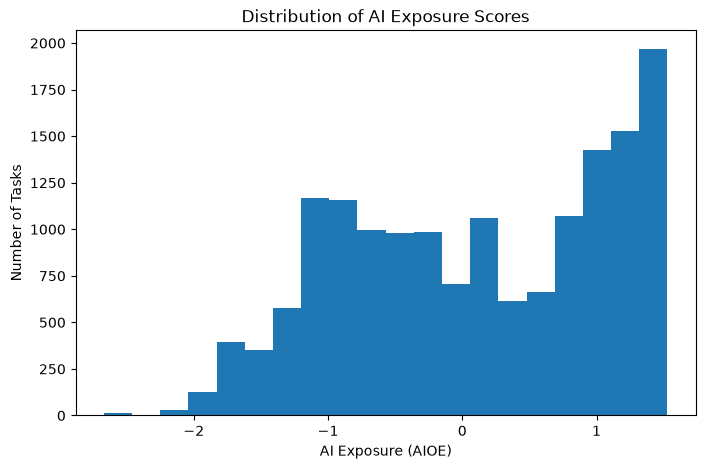

In [23]:
#4. Distribution of AI exposure
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(merged["AIOE"], bins=20)
plt.xlabel("AI Exposure (AIOE)")
plt.ylabel("Number of Tasks")
plt.title("Distribution of AI Exposure Scores")
plt.show()